In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install opencv-python

Looking in indexes: https://download.pytorch.org/whl/cpu


Saving people.jpg to people.jpg


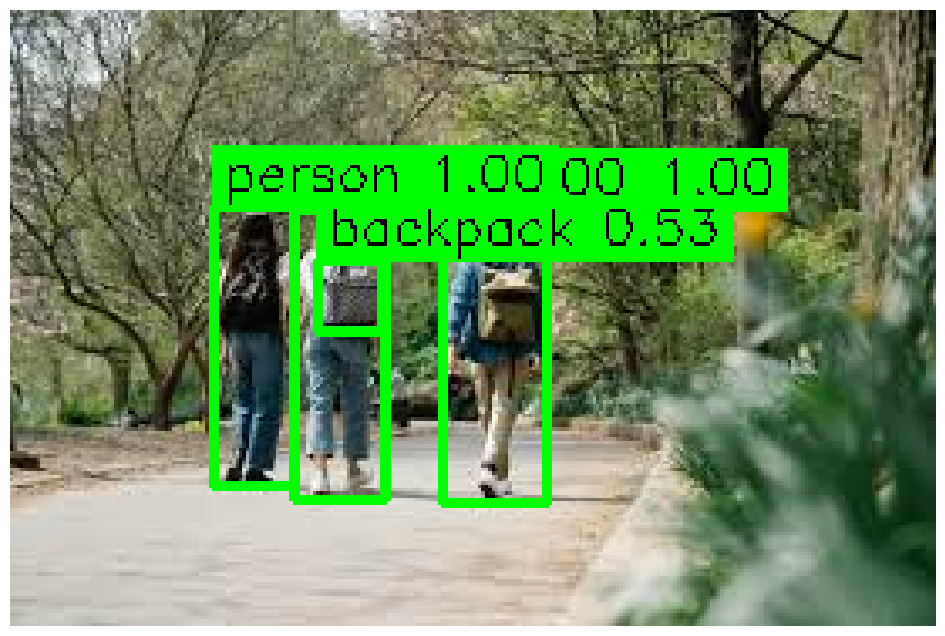

In [9]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from matplotlib import pyplot as plt
import numpy as np

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

labels = weights.meta["categories"]

# Upload image
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load image
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

tensor = F.to_tensor(image_rgb).unsqueeze(0)

# Run detection
with torch.no_grad():
    out = model(tensor)[0]

boxes = out['boxes']
scores = out['scores']
classes = out['labels']

# Draw
clean = image_rgb.copy()

for box, score, cls in zip(boxes, scores, classes):
    if score < 0.5:
        continue

    x1, y1, x2, y2 = box.int().tolist()

    label = f"{labels[cls]} {score:.2f}"

    # Draw box
    cv2.rectangle(clean, (x1, y1), (x2, y2), (0,255,0), 2)

    # --------------------------
    # Draw neat text background
    # --------------------------
    (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(clean, (x1, y1 - h - 6), (x1 + w + 6, y1), (0,255,0), -1)

    # Draw text
    cv2.putText(clean, label, (x1 + 3, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

# Show result
plt.figure(figsize=(12, 8))
plt.imshow(clean)
plt.axis('off')
plt.show()


Saving people.jpg to people (3).jpg


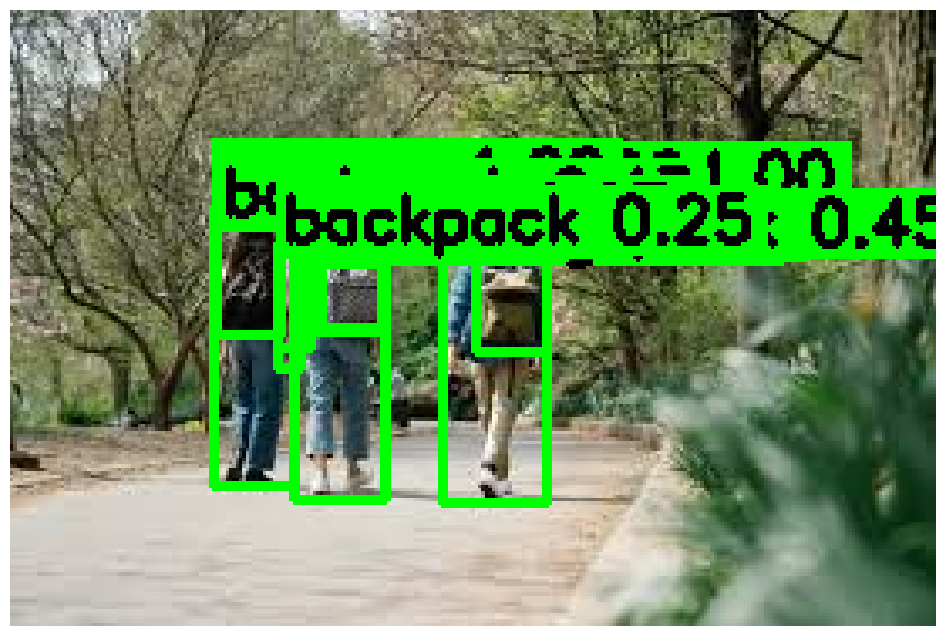

In [12]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from PIL import Image
import cv2
import numpy as np
from matplotlib import pyplot as plt

# --------------------------
# Load model
# --------------------------
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

labels = weights.meta["categories"]

# --------------------------
# Upload image
# --------------------------
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# --------------------------
# Read + convert to PIL
# --------------------------
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_pil = Image.fromarray(img_rgb)

# --------------------------
# Apply official preprocessing
# --------------------------
preprocess = weights.transforms()
input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

# --------------------------
# Run detection
# --------------------------
with torch.no_grad():
    output = model(input_tensor)[0]

boxes = output["boxes"].cpu()
scores = output["scores"].cpu()
classes = output["labels"].cpu()

# --------------------------
# Draw results
# --------------------------
result = img_rgb.copy()
CONF_THRESH = 0.25   # Adjust if needed

for box, score, cls in zip(boxes, scores, classes):
    if score < CONF_THRESH:
        continue

    x1, y1, x2, y2 = map(int, box.tolist())
    label = f"{labels[cls]} {score:.2f}"

    # Draw bounding box
    cv2.rectangle(result, (x1, y1), (x2, y2), (0,255,0), 2)

    # Background for label
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(result, (x1, y1 - th - 6), (x1 + tw + 4, y1), (0,255,0), -1)

    # Draw label
    cv2.putText(result, label, (x1 + 2, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

# --------------------------
# Show output
# --------------------------
plt.figure(figsize=(12, 8))
plt.imshow(result)
plt.axis("off")
plt.show()
